In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [40]:
merged_ground_truth_sentences = [
    "god sees man heart",
    "woman love sweet life",
    "father hear mother voice",
    "people build city town",
    "servant open temple gate",
    "man fear storm sky",
    "owl see night sky",
    "river flow west town",
    "mother give youth life",
    "god give people power",
    "man walk desert road",
    "woman carry water jar",
    "people love sweet peace",
    "cobra hide stone hill",
    "man see star sky",
    "servant bring offering temple",
    "father teach youth wisdom",
    "people build house town",
    "god watch people life",
    "man cut grain field",
    "woman plant grain field",
    "servant carry stone brick",
    "man hear storm river",
    "owl watch silent night",
    "people walk river road",
    "woman hold child heart",
    "god grant people life",
    "man see mountain horizon",
    "servant open house door",
    "people praise god temple",
    "mother love youth heart",
    "man climb hill stone",
    "woman fill water jar",
    "people follow desert road",
    "god bless people town",
    "man feel fear heart",
    "servant serve god temple",
    "people gather grain field",
    "woman see lake horizon",
    "man carry rope vessel",
    "people seek sweet peace",
    "god rule city town",
    "youth love sweet life",
    "man watch river flow",
    "woman bring offering temple",
    "people honor god throne",
    "servant clean house temple",
    "man feel strong power",
    "woman see star sky",
    "people build stone temple",
    "god protect people town",
    "man walk mountain road",
    "mother guide youth life",
    "people share sweet life",
    "servant guard temple gate",
    "man see cobra snake",
    "woman feel love heart",
    "people praise god power",
    "man drink water river",
    "people cross desert hill",
    "god sit throne temple",
    "woman carry vessel water",
    "man see fire storm",
    "people honor mother father",
    "servant bring grain offering",
    "youth seek sweet life",
    "man feel storm fear",
    "people walk west road",
    "god give strong power",
    "god see horizon sky",
    "woman walk riverbank road",
    "man lift stone strength",
    "people open town gate",
    "servant carry milk jar",
    "father give mother love",
    "youth climb desert hill",
    "god hear people prayer",
    "woman plant lotus field",
    "man feel heart fear",
    "people cross river rope",
    "servant guard city gate",
    "mother hold youth hand",
    "god watch lake horizon",
    "man bring bread offering",
    "woman see mountain horizon",
    "people gather papyrus clump",
    "servant fill vessel water",
    "father teach youth strength",
    "man follow twisted flax",
    "people honor seated god",
    "woman hear owl night",
    "god grant life ankh",
    "servant clean temple stool",
    "man see scarab become",
    "people build brick house",
    "mother give milk jar",
    "youth seek great power",
    "god protect town people",
    "woman feel sweet peace",
    "man watch swallow sky",
    "servant bring lotus plant",
    "people praise great god",
    "father guide youth road",
    "woman open jar water",
    "man climb mountain hill",
    "people carry rope vessel",
    "servant seat man throne",
    "god rule sky earth",
    "mother teach youth love",
    "man see star horizon",
    "people cross lake river",
    "woman hold heart life",
    "servant serve seated king",
    "youth feel strong power",
    "god hear servant voice",
    "man drink lake water",
    "people walk town road",
    "woman bring peace offering",
    "father hold youth hand",
    "servant guard house door",
    "god bless sweet life",
    "man feel fire heart",
    "people share bread offering",
    "woman see owl sky",
    "mother guide youth heart",
    "man lift grain sack",
    "people honor throne god",
    "servant open river gate",
    "youth climb hill slope",
    "god grant people peace",
    "woman carry papyrus scroll",
    "man follow desert road",
    "people gather lotus plant",
    "servant bring water ripple",
    "father teach youth power",
    "woman feel heart life",
    "man see storm sky",
    "people walk mountain road",
    "god protect temple gate",
    "god see riverbank people",
    "woman walk horizon road",
    "man carry stone vessel",
    "people open house gate",
    "servant bring grain jar",
    "father hear youth voice",
    "mother give sweet milk",
    "god watch desert hill",
    "woman plant reed leaf",
    "man feel strong heart",
    "people cross mountain pass",
    "servant guard throne seat",
    "youth climb great hill",
    "god grant soul life",
    "woman see lake riverbank",
    "man bring peace altar",
    "people gather papyrus scroll",
    "servant fill jar water",
    "father guide youth strength",
    "woman hear storm sky",
    "god bless field grain",
    "man see snake stone",
    "people build town temple",
    "mother hold youth face",
    "servant bring rope coil",
    "youth seek sweet peace",
    "god protect river town",
    "woman carry basket handle",
    "man feel fear storm",
    "people honor god power",
    "servant clean stool mat",
    "father teach youth heart",
    "woman see feather truth",
    "man drink river water",
    "people walk west riverbank",
    "god rule throne seat",
    "mother give life ankh",
    "servant open reed shelter",
    "youth climb mountain road",
    "god hear heart prayer",
    "woman bring lotus offering",
    "man see fire horizon",
    "people gather field grain",
    "servant guard city town",
    "father hold youth life",
    "woman feel sweet heart",
    "god bless seated king",
    "man carry tethering rope",
    "people cross desert road",
    "mother guide youth power",
    "servant bring papyrus scroll",
    "youth feel strong life",
    "god protect sky people",
    "woman see swallow great",
    "man lift brick stone",
    "people praise temple god",
    "servant seat seated man",
    "father teach youth road",
    "woman carry milk jar",
    "god grant great power",
    "man see owl night",
    "people walk hill slope",
    "servant bring peace satisfy",
    "youth seek strong life",
    "god watch star sky",
    "woman plant lotus plant",
    "man follow riverbank road",
    "people honor feather maat",
    "god see city town",
    "woman walk hill slope",
    "man carry basket lord",
    "people open temple door",
    "servant bring bread loaf",
    "father hear heart voice",
    "mother give youth milk",
    "god watch river west",
    "woman plant papyrus clump",
    "people cross rope river",
    "servant guard house gate",
    "youth climb desert mountain",
    "god grant great life",
    "woman see star horizon",
    "man bring sweet offering",
    "people gather lotus field",
    "servant fill vessel river",
    "woman hear owl sky",
    "god bless grain field",
    "man see cobra hill",
    "people build stone house",
    "mother hold youth heart",
    "servant bring twisted flax",
    "god protect lake town",
    "woman carry reed leaf",
    "servant clean reed shelter",
    "father teach youth love",
    "woman see ka spirit",
    "man drink water ripple",
    "people walk west horizon",
    "god rule seated throne",
    "mother give life spirit",
    "servant open door bolt",
    "youth climb hill stone",
    "god hear soul prayer",
    "woman bring peace altar",
    "people gather grain pellet",
    "servant guard town gate",
    "father hold youth power",
    "god bless seated god",
    "man carry rope coil",
    "mother guide youth strength",
    "servant bring papyrus clump",
    "youth feel strong heart",
    "god watch sky horizon",
    "woman see swallow sky",
    "man lift backbone stone",
    "servant seat throne king",
    "woman carry milk vessel",
    "man see owl star",
    "people walk riverbank road",
    "mother hold youth life",
    "youth seek strong power",
    "god protect field people",
    "woman plant reed shelter",
    "man follow mountain road",
    "people honor maat feather",
    "god see river horizon",
    "woman walk town road",
    "man carry milk jar",
    "people open city gate",
    "servant bring grain pellet",
    "father hear storm sky",
    "mother give youth heart",
    "god watch mountain horizon",
    "man feel strong force",
    "people cross lake rope",
    "servant guard temple throne",
    "god grant power people",
    "woman see papyrus scroll",
    "man bring peace satisfy",
    "people gather reed leaf",
    "servant fill jar milk",
    "father guide youth life",
    "woman hear swallow sky",
    "man see snake desert",
    "people build brick temple",
    "mother hold youth power",
    "servant bring three fox",
    "god protect west town",
    "man feel heart life",
    "people honor seated king",
    "woman see ka double",
    "man drink lake ripple",
    "people walk desert hill",
    "god rule sky star",
    "mother give soul life",
    "servant open reed gate",
    "youth climb stone hill",
    "god hear heart people",
    "woman bring peace content",
    "servant guard riverbank town",
    "father hold youth road",
    "god bless great power",
    "people cross mountain road",
    "mother guide youth love",
    "god watch star horizon",
    "woman see owl night",
    "man lift brick backbone",
    "people praise seated god",
    "servant seat seated woman",
    "god grant sweet life",
    "man see desert hare",
    "people walk river west",
    "mother hold youth strength",
    "servant bring peace altar",
    "woman plant papyrus field",
    "man follow hill road",
    "people honor soul ba",
    "god see desert hill",
    "woman walk river road",
    "man carry grain jar",
    "people open town door",
    "servant bring peace offering",
    "father hear owl night",
    "mother give youth strength",
    "god watch sky people",
    "woman plant reed field",
    "man feel heart power",
    "people cross riverbank hill",
    "servant guard seated king",
    "youth climb mountain stone",
    "god grant soul people",
    "woman see lake sky",
    "man bring sweet bread",
    "servant fill vessel milk",
    "father guide youth heart",
    "woman hear storm horizon",
    "god bless lotus plant",
    "man see horned viper",
    "people build city temple",
    "servant bring basket lord",
    "youth seek strong heart",
    "god protect mountain town",
    "woman carry papyrus clump",
    "servant clean reed mat",
    "father teach youth life",
    "man drink river ripple",
    "people walk desert road",
    "god rule star sky",
    "mother give sweet life",
    "god hear people heart",
    "man see fire sky",
    "servant guard house temple",
    "woman feel heart peace",
    "god bless great life",
    "people cross west river",
    "mother guide youth road",
    "god watch horizon town",
    "man lift stone brick",
    "people praise god throne",
    "god grant strong power",
    "man see owl sky",
    "people walk mountain path",
    "god protect field town",
    "man follow river road",
    "people honor feather truth",
    "god see hill horizon",
    "woman walk field road",
    "man carry vessel water",
    "people open reed shelter",
    "servant bring lotus offering",
    "father hear river flow",
    "mother give youth power",
    "god watch temple gate",
    "man feel strong life",
    "people cross town road",
    "servant guard riverbank gate",
    "youth climb desert slope",
    "woman see mountain sky",
    "man bring milk jar",
    "people gather reed shelter",
    "servant fill grain basket",
    "father guide youth love",
    "woman hear wind storm",
    "god bless city people",
    "man see head ox",
    "people build temple pillar",
    "mother hold youth soul",
    "youth seek heart peace",
    "god protect desert town",
    "man feel fire strength",
    "servant clean stone stool",
    "people walk horizon west",
    "god rule mountain sky",
    "mother give sweet heart",
    "servant open town gate",
    "youth climb rocky hill",
    "god hear soul voice",
    "man see star river",
    "people gather papyrus field",
    "father hold youth strength",
    "woman feel sweet life",
    "god bless strong power",
    "people cross lake shore",
    "mother guide youth soul",
    "youth feel heart life",
    "god watch west horizon",
    "woman see owl river",
    "man lift sickle grain",
    "people praise god city",
    "father teach youth peace",
    "man see desert mountain",
    "people walk hill road",
    "mother hold youth love",
    "youth seek soul life",
    "god protect river people",
    "woman plant lotus garden",
    "man follow town road",
    "god see lake horizon",
    "woman walk mountain road",
    "man carry jar water",
    "people open city door",
    "servant bring sweet bread",
    "father hear people voice",
    "mother give youth soul",
    "god watch field grain",
    "man feel heart strength",
    "people cross hill slope",
    "servant guard temple door",
    "youth climb stone mountain",
    "god grant sweet peace",
    "woman see river west",
    "man bring peace content",
    "people gather milk jar",
    "servant fill water vessel",
    "father guide youth soul",
    "woman hear desert wind",
    "god bless throne temple",
    "man see head bird",
    "people build river town",
    "mother hold youth peace",
    "servant bring reed leaf",
    "youth seek strong soul",
    "god protect sky town",
    "woman carry twisted flax",
    "people honor great god",
    "servant clean house mat",
    "father teach youth soul",
    "woman see feather maat",
    "people walk riverbank west",
    "god rule city people",
    "servant open house bolt",
    "god hear heart soul",
    "woman bring lotus altar",
    "man see storm horizon",
    "servant guard lake gate",
    "father hold youth peace",
    "woman feel strong heart",
    "god bless soul life",
    "man carry basket handle",
    "people cross mountain hill",
    "mother guide youth spirit",
    "servant bring reed shelter",
    "youth feel sweet life",
    "god watch desert town",
    "woman see swallow river",
    "man lift stone pillar",
    "servant seat seated god",
    "god grant soul peace",
    "man see cobra stone",
    "people walk sky horizon",
    "youth seek heart life",
    "god protect grain field",
    "man follow west road",
    "people honor ka spirit",
    "god see mountain horizon",
    "woman walk riverbank path",
    "man carry grain vessel",
    "people open temple gate",
    "servant bring milk offering",
    "father hear wind storm",
    "mother give youth peace",
    "god watch lotus field",
    "man feel strong soul",
    "servant guard city throne",
    "god grant heart life",
    "woman see sky star",
    "man bring bread loaf",
    "servant fill milk jar",
    "father guide youth power",
    "woman hear river ripple",
    "god bless seated throne",
    "people build town pillar",
    "mother hold youth spirit",
    "servant bring twisted rope",
    "youth seek sweet heart",
    "god protect west people",
    "woman carry vessel grain",
    "man feel fire soul",
    "people honor god temple",
    "servant clean reed stool",
    "woman see ka life",
    "god rule horizon sky",
    "mother give strong life",
    "servant open city bolt",
    "youth climb rocky slope",
    "god hear soul people",
    "man see owl horizon",
    "people gather lotus altar",
    "servant guard river gate",
    "woman feel sweet soul",
    "man carry coil rope",
    "people cross hill road",
    "servant bring grain basket",
    "youth feel strong soul",
    "god watch town horizon",
    "woman see swallow west",
    "servant seat seated king",
    "woman carry jar milk",
    "god grant strong life",
    "man see desert hill",
    "youth seek soul peace",
    "god protect mountain people",
    "man follow horizon road",
    "god see desert horizon",
    "woman walk lake road",
    "people open river gate",
    "father hear heart prayer",
    "god watch hill sky",
    "man feel strong spirit",
    "people cross town bridge",
    "servant guard temple pillar",
    "youth climb mountain slope",
    "woman see west horizon",
    "man bring milk vessel",
    "servant fill grain jar",
    "father guide youth peace",
    "woman hear night owl",
    "god bless river people",
    "god protect sky city",
    "woman carry basket grain",
    "people honor god city",
    "servant clean temple mat",
    "people walk mountain horizon",
    "god rule throne sky",
    "mother give sweet peace",
    "servant open gate bolt",
    "youth climb hill ridge",
    "god hear people soul",
    "man see storm river",
    "servant guard town door",
    "father hold youth soul",
    "god bless strong life",
    "people cross river west",
    "youth feel sweet soul",
    "woman carry jar water",
    "man see owl hill",
    "people walk desert path",
    "god protect grain town",
    "god sees beautiful heart",
    "scribe hears great king",
    "man loves beautiful woman",
    "king opens great gate",
    "servant plows great field",
    "father loves beautiful youth",
    "man becomes great king",
    "god gives life heart",
    "woman sees beautiful star",
    "scribe sees great riverbank",
    "king makes great house",
    "god loves sweet offering",
    "servant hears master authority",
    "cobra emerges behind hill",
    "heart becomes great peace",
    "man hears great god",
    "scribe makes beautiful writing",
    "mother gives loaf bread",
    "servant opens house gate",
    "king gives great throne",
    "man speaks great truth",
    "bird eats grain pellet",
    "woman sees beautiful lake",
    "god hears beautiful soul",
    "scribe hears great power",
    "mother sees beautiful youth",
    "king hears great people",
    "servant sees great mountain",
    "god makes beautiful sky",
    "man finds great stone",
    "old man cuts plant",
    "snake emerges above desert",
    "strong hand makes brick",
    "swallow eats quail chick",
    "scribe finds papyrus scroll",
    "king sees city town",
    "servant gives milk jar",
    "god hears great fear",
    "man sees road west",
    "mighty storm becomes fire",
    "youth finds stone chisel",
    "father gives seated god",
    "woman eats sweet loaf",
    "scarab becomes great god",
    "hand makes coil rope",
    "king gives basket handle",
    "eye sees animal belly",
    "master hears mighty storm",
    "soul becomes star above",
    "god gives stability djed",
    "scribe makes beautiful book",
    "woman sees lotus plant",
    "old man speaks truth",
    "king sees seat throne",
    "servant plows field hoe",
    "man cuts rope sickle",
    "father hears bird head",
    "god makes great horizon",
    "people fear great snake",
    "strong club cuts plant",
    "scarab becomes stone ring",
    "mother makes sweet loaf",
    "bird emerges above hill",
    "scribe hears king authority",
    "god gives life soul",
    "woman sees riverbank road",
    "youth sees desert hill",
    "man finds door bolt",
    "servant gives bread offering",
    "strong king becomes god",
    "adze cuts great stone",
    "horned viper emerges hill",
    "mouth speaks feather truth",
    "man sees mountain road",
    "youth gives milk jar",
    "father sees great city",
    "god loves beautiful soul",
    "servant makes loaf bread",
    "snake eats quail chick",
    "king sees horizon star",
    "heart hears god authority",
    "mother gives sweet offering",
    "scribe makes papyrus clump",
    "strong man plows field",
    "face sees beautiful sky",
    "soul becomes great god",
    "hand gives water ripple",
    "pillar gives stability djed",
    "old man hears king",
    "youth finds stone ring",
    "desert hare sees hill",
    "cobra emerges water ripple",
    "master gives great power",
    "king sees reed shelter",
    "scribe finds stone chisel",
    "man makes basket handle",
    "heart finds great peace",
    "strong club cuts brick",
    "king hears people fear",
    "servant sees jars rack",
    "god gives life ankh",
    "scribe makes book scroll",
    "animal belly finds water",
    "hand makes door bolt",
    "mouth speaks sweet truth",
    "father makes reed shelter",
    "woman sees swallow head",
    "king makes great temple",
    "youth hears old man",
    "god sees heart truth",
    "man gives stone vessel",
    "scribe hears great lord",
    "foot finds mountain road",
    "heart loves beautiful life",
    "fire emerges above hill",
    "hand makes stone adze",
    "king sees desert hill",
    "servant hears master speak",
    "scribe sees great town",
    "backbone gives great power",
    "eye sees senet board",
    "ka spirit becomes god",
    "king finds stone ring",
    "man loves seated woman",
    "mother makes folded cloth",
    "owl sees quail chick",
    "scribe makes brick house",
    "servant hears master power",
    "woman finds lotus plant",
    "youth sees desert hare",
    "cobra finds animal belly",
    "god gives stability stone",
    "hand makes tethering rope",
    "heart finds sweet peace",
    "king sees hill slope",
    "mouth eats grain pellet",
    "old man hears bird",
    "people fear mighty storm",
    "scribe sees jars rack",
    "servant gives conical loaf",
    "snake emerges hill slope",
    "soul finds peace altar",
    "stone adze cuts plant",
    "water ripple becomes lake",
    "woman gives milk jar",
    "youth finds door bolt",
    "scribe sees three skins",
    "king makes great city",
    "father loves beautiful mother",
    "fire becomes great thing",
    "god loves heart truth",
    "hand finds reed leaf",
    "man sees horizon star",
    "mouth speaks beautiful truth",
    "scribe finds stone vessel",
    "servant hears king speak",
    "woman makes sweet offering",
    "youth sees reed shelter",
    "mighty lord sees people",
    "scribe makes scroll book",
    "king sees stone throne",
    "soul ba becomes star",
    "stone chisel cuts brick",
    "swallow finds grain pellet",
    "temple gate becomes strong",
    "woman finds basket handle",
    "youth hears god speak",
    "master gives great thing",
    "father sees riverbank road",
    "man sees desert hare",
    "scribe finds door bolt",
    "servant makes twisted flax",
    "man eats grain pellet",
    "youth sees lotus plant",
    "servant finds reed shelter",
    "father makes reed leaf",
    "servant makes folded cloth",
    "scribe sees papyrus scroll",
    "king hears mighty storm",
    "servant plows hill field",
    "god loves beautiful people",
    "soul ba finds peace",
    "eye sees hill slope",
    "mouth speaks sweet peace",
    "old man finds mountain",
    "people find great thing",
    "snake emerges above hill",
    "water ripple becomes river",
    "youth hears master authority",
    "woman finds milk jar",
    "man sees animal belly",
    "scribe finds stone adze",
    "king makes big town",
    "mother gives conical loaf",
    "god gives great life",
    "heart finds sweet life",
    "father finds great road",
    "man cuts plant sickle",
    "youth sees desert snake",
    "scribe hears master speak",
    "woman loves seated man",
    "king gives power authority",
    "servant sees great temple",
    "god hears sweet truth",
    "soul finds great altar",
    "old man speaks peace",
    "servant finds reed leaf",
    "mouth eats sweet loaf",
    "people fear mighty fire",
    "snake eats animal belly",
    "water ripple becomes big",
    "youth sees great town",
    "scribe makes great book",
    "king sees beautiful horizon",
    "woman sees beautiful face",
    "man finds stone vessel",
    "sedge king sees people",
    "heart finds great fear",
    "hand finds stone chisel",
    "scribe makes twisted flax",
    "youth finds senet board",
    "mother sees bird head",
    "father gives three skins",
    "king finds tethering rope",
    "god sees papyrus clump",
    "servant finds door bolt",
    "man hears mighty fire",
    "woman finds stone vessel",
    "king makes stone temple",
    "god gives life spirit",
    "soul ba finds life",
    "snake finds quail chick",
    "horned viper finds desert",
    "scribe sees beautiful writing",
    "father finds milk jar",
    "man finds stone brick",
    "youth finds great mountain",
    "heart loves beautiful truth",
    "master hears scribe speak",
    "people find great soul",
    "god sees beautiful horizon",
    "hand finds coil rope",
    "scribe gives papyrus scroll",
    "woman sees basket handle",
    "man finds desert hare",
    "god gives stability pillar",
    "heart finds sweet love",
    "youth finds stone adze",
    "mother finds bread loaf",
    "king finds horizon star",
    "water ripple finds lake",
    "people love great king",
    "old man sees god",
    "face sees great god",
    "scribe makes stone brick",
    "hand makes twisted flax",
    "youth sees door bolt",
    "mouth finds grain pellet",
    "soul ba sees star",
    "god gives life power",
    "king sees beautiful city",
    "woman loves lotus plant",
    "servant makes reed shelter",
    "scribe sees stone chisel",
    "god hears sweet offering",
    "king makes stone throne"
]

In [41]:

# Raw Data provided by user
shuffled_sentences_raw = [
"""man
sees
heart
god""",
"""life
sweet
woman
love""",
"""hear
voice
mother
father""",
"""build
city
people
town""",
"""open
temple
gate
servant""",
"""fear
sky
storm
man""",
"""night
see
owl
sky""",
"""flow
town
river
west""",
"""mother
youth
give
life""",
"""people
power
god
give""",
"""desert
walk
road
man""",
"""jar
water
carry
woman""",
"""peace
love
people
sweet""",
"""stone
hill
hide
cobra""",
"""man
see
sky
star""",
"""temple
servant
offering
bring""",
"""teach
wisdom
youth
father""",
"""build
town
people
house""",
"""life
people
watch
god""",
"""man
cut
grain
field""",
"""woman
grain
field
plant""",
"""servant
brick
stone
carry""",
"""hear
river
storm
man""",
"""silent
night
owl
watch""",
"""river
people
walk
road""",
"""hold
heart
woman
child""",
"""life
people
grant
god""",
"""see
horizon
man
mountain""",
"""door
open
servant
house""",
"""people
praise
god
temple""",
"""youth
mother
heart
love""",
"""man
stone
hill
climb""",
"""woman
fill
water
jar""",
"""follow
road
people
desert""",
"""bless
people
god
town""",
"""feel
fear
heart
man""",
"""serve
servant
god
temple""",
"""people
grain
gather
field""",
"""see
woman
horizon
lake""",
"""vessel
carry
rope
man""",
"""peace
seek
people
sweet""",
"""city
rule
god
town""",
"""life
love
sweet
youth""",
"""flow
man
river
watch""",
"""bring
woman
temple
offering""",
"""god
people
throne
honor""",
"""temple
clean
house
servant""",
"""feel
strong
man
power""",
"""sky
woman
see
star""",
"""build
stone
temple
people""",
"""town
protect
people
god""",
"""walk
road
mountain
man""",
"""mother
life
youth
guide""",
"""people
sweet
life
share""",
"""gate
servant
temple
guard""",
"""man
snake
see
cobra""",
"""woman
feel
love
heart""",
"""praise
god
power
people""",
"""water
river
drink
man""",
"""hill
people
desert
cross""",
"""sit
throne
temple
god""",
"""water
vessel
woman
carry""",
"""see
storm
man
fire""",
"""people
honor
father
mother""",
"""offering
servant
grain
bring""",
"""sweet
seek
youth
life""",
"""feel
storm
man
fear""",
"""road
walk
west
people""",
"""god
power
give
strong""",
"""see
god
horizon
sky""",
"""riverbank
walk
road
woman""",
"""lift
strength
man
stone""",
"""town
gate
people
open""",
"""milk
servant
jar
carry""",
"""love
father
give
mother""",
"""desert
hill
climb
youth""",
"""hear
prayer
people
god""",
"""plant
lotus
field
woman""",
"""man
heart
feel
fear""",
"""river
people
rope
cross""",
"""city
servant
gate
guard""",
"""mother
youth
hold
hand""",
"""god
horizon
watch
lake""",
"""bread
offering
man
bring""",
"""horizon
mountain
woman
see""",
"""gather
clump
people
papyrus""",
"""fill
servant
vessel
water""",
"""teach
strength
youth
father""",
"""flax
twisted
man
follow""",
"""seated
people
god
honor""",
"""night
woman
owl
hear""",
"""ankh
life
grant
god""",
"""stool
clean
servant
temple""",
"""man
scarab
become
see""",
"""people
house
brick
build""",
"""milk
mother
give
jar""",
"""great
power
seek
youth""",
"""protect
people
town
god""",
"""peace
feel
woman
sweet""",
"""swallow
watch
sky
man""",
"""plant
bring
servant
lotus""",
"""praise
people
god
great""",
"""guide
father
road
youth""",
"""jar
woman
water
open""",
"""climb
hill
mountain
man""",
"""vessel
people
carry
rope""",
"""throne
seat
servant
man""",
"""sky
god
rule
earth""",
"""love
teach
youth
mother""",
"""see
horizon
man
star""",
"""river
cross
people
lake""",
"""woman
life
heart
hold""",
"""serve
servant
seated
king""",
"""feel
strong
power
youth""",
"""servant
voice
hear
god""",
"""drink
lake
man
water""",
"""road
people
walk
town""",
"""bring
offering
woman
peace""",
"""hand
youth
hold
father""",
"""door
house
servant
guard""",
"""sweet
god
life
bless""",
"""man
heart
fire
feel""",
"""share
people
bread
offering""",
"""see
sky
woman
owl""",
"""youth
guide
mother
heart""",
"""grain
sack
man
lift""",
"""god
people
honor
throne""",
"""gate
river
servant
open""",
"""youth
hill
climb
slope""",
"""peace
people
grant
god""",
"""woman
carry
papyrus
scroll""",
"""desert
follow
road
man""",
"""people
plant
lotus
gather""",
"""water
bring
ripple
servant""",
"""father
teach
power
youth""",
"""feel
woman
heart
life""",
"""see
man
storm
sky""",
"""road
walk
people
mountain""",
"""protect
gate
temple
god""",
"""people
god
see
riverbank""",
"""woman
walk
road
horizon""",
"""vessel
carry
stone
man""",
"""people
open
gate
house""",
"""servant
jar
bring
grain""",
"""youth
voice
father
hear""",
"""give
mother
sweet
milk""",
"""hill
god
watch
desert""",
"""leaf
woman
plant
reed""",
"""man
feel
strong
heart""",
"""people
mountain
cross
pass""",
"""servant
seat
throne
guard""",
"""hill
youth
great
climb""",
"""god
grant
life
soul""",
"""lake
see
riverbank
woman""",
"""altar
peace
man
bring""",
"""gather
papyrus
scroll
people""",
"""fill
servant
jar
water""",
"""youth
father
guide
strength""",
"""woman
storm
hear
sky""",
"""grain
field
god
bless""",
"""snake
stone
see
man""",
"""people
temple
town
build""",
"""hold
face
youth
mother""",
"""rope
coil
bring
servant""",
"""youth
seek
sweet
peace""",
"""god
protect
river
town""",
"""basket
carry
woman
handle""",
"""fear
man
feel
storm""",
"""people
honor
power
god""",
"""servant
stool
mat
clean""",
"""heart
teach
youth
father""",
"""woman
feather
truth
see""",
"""drink
man
water
river""",
"""riverbank
west
people
walk""",
"""rule
god
throne
seat""",
"""life
ankh
mother
give""",
"""servant
reed
open
shelter""",
"""climb
mountain
youth
road""",
"""heart
god
hear
prayer""",
"""lotus
woman
bring
offering""",
"""man
horizon
see
fire""",
"""gather
people
field
grain""",
"""city
guard
servant
town""",
"""youth
father
hold
life""",
"""woman
sweet
feel
heart""",
"""seated
god
king
bless""",
"""tethering
rope
carry
man""",
"""road
cross
desert
people""",
"""youth
mother
power
guide""",
"""scroll
papyrus
bring
servant""",
"""life
feel
youth
strong""",
"""god
people
protect
sky""",
"""woman
great
see
swallow""",
"""brick
stone
lift
man""",
"""temple
god
praise
people""",
"""seat
man
seated
servant""",
"""teach
youth
road
father""",
"""carry
jar
milk
woman""",
"""great
power
god
grant""",
"""see
night
owl
man""",
"""people
walk
hill
slope""",
"""bring
satisfy
servant
peace""",
"""strong
youth
life
seek""",
"""sky
star
watch
god""",
"""plant
woman
lotus
plant""",
"""follow
road
riverbank
man""",
"""maat
honor
feather
people""",
"""see
town
city
god""",
"""woman
walk
slope
hill""",
"""lord
carry
man
basket""",
"""door
temple
open
people""",
"""loaf
bread
bring
servant""",
"""hear
father
heart
voice""",
"""youth
give
mother
milk""",
"""god
river
watch
west""",
"""clump
woman
plant
papyrus""",
"""river
rope
cross
people""",
"""servant
house
gate
guard""",
"""mountain
climb
youth
desert""",
"""life
grant
god
great""",
"""woman
star
horizon
see""",
"""man
offering
bring
sweet""",
"""gather
field
lotus
people""",
"""vessel
fill
river
servant""",
"""hear
woman
owl
sky""",
"""god
bless
grain
field""",
"""see
cobra
man
hill""",
"""house
build
people
stone""",
"""mother
youth
heart
hold""",
"""servant
bring
twisted
flax""",
"""god
protect
lake
town""",
"""woman
carry
leaf
reed""",
"""servant
shelter
clean
reed""",
"""love
youth
father
teach""",
"""see
spirit
woman
ka""",
"""water
ripple
man
drink""",
"""people
walk
horizon
west""",
"""seated
rule
throne
god""",
"""life
mother
spirit
give""",
"""open
bolt
servant
door""",
"""climb
stone
youth
hill""",
"""hear
god
prayer
soul""",
"""bring
peace
woman
altar""",
"""people
pellet
gather
grain""",
"""town
servant
guard
gate""",
"""power
youth
hold
father""",
"""seated
bless
god
god""",
"""carry
rope
man
coil""",
"""youth
strength
mother
guide""",
"""bring
papyrus
clump
servant""",
"""feel
youth
strong
heart""",
"""god
sky
watch
horizon""",
"""woman
see
sky
swallow""",
"""lift
man
stone
backbone""",
"""seat
throne
king
servant""",
"""carry
woman
vessel
milk""",
"""star
owl
man
see""",
"""walk
riverbank
road
people""",
"""mother
youth
hold
life""",
"""seek
power
youth
strong""",
"""god
protect
people
field""",
"""plant
reed
woman
shelter""",
"""follow
man
road
mountain""",
"""honor
maat
people
feather""",
"""river
god
horizon
see""",
"""walk
town
road
woman""",
"""man
carry
jar
milk""",
"""city
open
people
gate""",
"""servant
bring
pellet
grain""",
"""father
hear
sky
storm""",
"""give
youth
mother
heart""",
"""god
watch
mountain
horizon""",
"""feel
force
man
strong""",
"""rope
people
lake
cross""",
"""guard
servant
throne
temple""",
"""god
power
people
grant""",
"""scroll
see
woman
papyrus""",
"""peace
bring
man
satisfy""",
"""people
leaf
gather
reed""",
"""fill
servant
milk
jar""",
"""father
youth
life
guide""",
"""woman
swallow
hear
sky""",
"""snake
desert
see
man""",
"""people
temple
build
brick""",
"""youth
power
hold
mother""",
"""three
servant
bring
fox""",
"""god
town
west
protect""",
"""man
feel
heart
life""",
"""seated
honor
king
people""",
"""woman
ka
double
see""",
"""drink
lake
man
ripple""",
"""hill
people
desert
walk""",
"""rule
god
star
sky""",
"""give
soul
mother
life""",
"""reed
gate
open
servant""",
"""youth
stone
hill
climb""",
"""god
people
hear
heart""",
"""peace
bring
woman
content""",
"""riverbank
servant
town
guard""",
"""youth
road
father
hold""",
"""god
great
bless
power""",
"""road
mountain
cross
people""",
"""youth
guide
mother
love""",
"""god
star
watch
horizon""",
"""woman
owl
see
night""",
"""backbone
man
brick
lift""",
"""seated
praise
people
god""",
"""woman
seated
seat
servant""",
"""sweet
god
grant
life""",
"""see
desert
man
hare""",
"""west
walk
people
river""",
"""strength
hold
youth
mother""",
"""bring
altar
peace
servant""",
"""plant
woman
papyrus
field""",
"""road
hill
follow
man""",
"""people
honor
ba
soul""",
"""hill
desert
see
god""",
"""woman
walk
road
river""",
"""carry
jar
grain
man""",
"""people
door
town
open""",
"""offering
servant
peace
bring""",
"""hear
owl
father
night""",
"""youth
give
mother
strength""",
"""sky
watch
people
god""",
"""field
reed
plant
woman""",
"""power
man
feel
heart""",
"""people
hill
riverbank
cross""",
"""king
seated
servant
guard""",
"""stone
climb
mountain
youth""",
"""soul
god
people
grant""",
"""woman
lake
sky
see""",
"""sweet
man
bring
bread""",
"""vessel
servant
fill
milk""",
"""heart
youth
guide
father""",
"""woman
hear
horizon
storm""",
"""god
plant
bless
lotus""",
"""man
horned
viper
see""",
"""city
build
temple
people""",
"""servant
bring
lord
basket""",
"""heart
seek
youth
strong""",
"""protect
town
god
mountain""",
"""papyrus
woman
carry
clump""",
"""clean
mat
servant
reed""",
"""teach
father
life
youth""",
"""drink
ripple
river
man""",
"""road
people
walk
desert""",
"""rule
god
sky
star""",
"""life
sweet
give
mother""",
"""hear
people
god
heart""",
"""man
sky
fire
see""",
"""temple
guard
servant
house""",
"""woman
heart
feel
peace""",
"""great
life
bless
god""",
"""west
river
people
cross""",
"""road
guide
mother
youth""",
"""horizon
town
watch
god""",
"""man
stone
lift
brick""",
"""people
praise
god
throne""",
"""grant
power
strong
god""",
"""owl
see
man
sky""",
"""path
people
mountain
walk""",
"""god
protect
field
town""",
"""follow
river
man
road""",
"""feather
honor
truth
people""",
"""see
hill
god
horizon""",
"""road
woman
field
walk""",
"""man
vessel
carry
water""",
"""open
people
reed
shelter""",
"""bring
servant
lotus
offering""",
"""father
hear
river
flow""",
"""power
give
mother
youth""",
"""god
temple
gate
watch""",
"""strong
man
life
feel""",
"""people
cross
road
town""",
"""gate
riverbank
guard
servant""",
"""desert
slope
youth
climb""",
"""see
sky
mountain
woman""",
"""milk
bring
jar
man""",
"""shelter
reed
people
gather""",
"""fill
basket
grain
servant""",
"""youth
love
father
guide""",
"""storm
woman
wind
hear""",
"""bless
people
god
city""",
"""see
ox
man
head""",
"""build
temple
pillar
people""",
"""soul
hold
mother
youth""",
"""heart
seek
peace
youth""",
"""desert
protect
town
god""",
"""feel
strength
fire
man""",
"""servant
stone
clean
stool""",
"""horizon
west
walk
people""",
"""sky
rule
mountain
god""",
"""give
mother
sweet
heart""",
"""gate
town
open
servant""",
"""climb
youth
rocky
hill""",
"""god
hear
soul
voice""",
"""star
see
river
man""",
"""field
papyrus
people
gather""",
"""father
hold
strength
youth""",
"""woman
feel
sweet
life""",
"""god
bless
strong
power""",
"""cross
shore
lake
people""",
"""mother
youth
soul
guide""",
"""youth
heart
life
feel""",
"""god
west
watch
horizon""",
"""river
owl
see
woman""",
"""man
lift
grain
sickle""",
"""city
praise
people
god""",
"""teach
youth
peace
father""",
"""desert
mountain
see
man""",
"""walk
road
people
hill""",
"""hold
mother
love
youth""",
"""youth
soul
seek
life""",
"""people
river
protect
god""",
"""plant
garden
woman
lotus""",
"""man
road
town
follow""",
"""lake
horizon
god
see""",
"""road
walk
woman
mountain""",
"""jar
man
water
carry""",
"""open
door
people
city""",
"""servant
bring
bread
sweet""",
"""voice
father
hear
people""",
"""youth
soul
mother
give""",
"""watch
field
grain
god""",
"""feel
strength
heart
man""",
"""people
hill
cross
slope""",
"""door
guard
servant
temple""",
"""youth
climb
mountain
stone""",
"""grant
sweet
peace
god""",
"""west
woman
river
see""",
"""content
peace
bring
man""",
"""people
milk
gather
jar""",
"""water
servant
fill
vessel""",
"""soul
youth
guide
father""",
"""wind
desert
hear
woman""",
"""bless
temple
god
throne""",
"""see
man
head
bird""",
"""river
build
town
people""",
"""youth
peace
mother
hold""",
"""leaf
servant
bring
reed""",
"""soul
strong
seek
youth""",
"""sky
town
god
protect""",
"""woman
flax
twisted
carry""",
"""great
god
honor
people""",
"""house
clean
servant
mat""",
"""soul
youth
teach
father""",
"""woman
see
feather
maat""",
"""west
walk
people
riverbank""",
"""city
people
rule
god""",
"""servant
open
house
bolt""",
"""heart
soul
hear
god""",
"""woman
lotus
altar
bring""",
"""horizon
storm
see
man""",
"""gate
guard
servant
lake""",
"""peace
youth
father
hold""",
"""woman
strong
heart
feel""",
"""life
soul
god
bless""",
"""basket
man
handle
carry""",
"""hill
people
mountain
cross""",
"""youth
guide
spirit
mother""",
"""servant
bring
reed
shelter""",
"""youth
feel
life
sweet""",
"""desert
god
town
watch""",
"""woman
swallow
see
river""",
"""lift
man
pillar
stone""",
"""seat
servant
god
seated""",
"""god
peace
grant
soul""",
"""cobra
see
stone
man""",
"""walk
horizon
people
sky""",
"""heart
youth
seek
life""",
"""protect
god
grain
field""",
"""man
follow
road
west""",
"""ka
spirit
people
honor""",
"""mountain
horizon
see
god""",
"""path
riverbank
woman
walk""",
"""grain
man
carry
vessel""",
"""people
gate
open
temple""",
"""servant
milk
bring
offering""",
"""storm
hear
wind
father""",
"""youth
peace
give
mother""",
"""god
lotus
watch
field""",
"""strong
man
soul
feel""",
"""servant
city
throne
guard""",
"""grant
heart
god
life""",
"""woman
see
star
sky""",
"""bring
loaf
man
bread""",
"""servant
fill
milk
jar""",
"""power
youth
guide
father""",
"""river
ripple
woman
hear""",
"""bless
seated
god
throne""",
"""pillar
town
people
build""",
"""hold
spirit
mother
youth""",
"""bring
servant
rope
twisted""",
"""seek
sweet
youth
heart""",
"""people
god
west
protect""",
"""vessel
carry
woman
grain""",
"""feel
man
soul
fire""",
"""people
honor
god
temple""",
"""clean
reed
servant
stool""",
"""life
woman
see
ka""",
"""god
rule
sky
horizon""",
"""mother
strong
give
life""",
"""open
city
servant
bolt""",
"""rocky
youth
slope
climb""",
"""soul
god
hear
people""",
"""owl
horizon
see
man""",
"""people
lotus
altar
gather""",
"""river
servant
gate
guard""",
"""woman
sweet
soul
feel""",
"""coil
rope
carry
man""",
"""people
cross
hill
road""",
"""grain
servant
basket
bring""",
"""feel
soul
youth
strong""",
"""horizon
watch
god
town""",
"""west
swallow
woman
see""",
"""king
servant
seat
seated""",
"""jar
woman
carry
milk""",
"""strong
grant
life
god""",
"""desert
hill
man
see""",
"""soul
peace
seek
youth""",
"""protect
people
god
mountain""",
"""man
horizon
road
follow""",
"""desert
see
horizon
god""",
"""walk
road
lake
woman""",
"""people
river
gate
open""",
"""prayer
hear
heart
father""",
"""god
sky
hill
watch""",
"""spirit
man
strong
feel""",
"""cross
bridge
people
town""",
"""temple
servant
guard
pillar""",
"""youth
mountain
climb
slope""",
"""west
horizon
see
woman""",
"""bring
vessel
man
milk""",
"""fill
jar
servant
grain""",
"""father
guide
peace
youth""",
"""woman
owl
night
hear""",
"""bless
god
river
people""",
"""sky
city
god
protect""",
"""basket
grain
carry
woman""",
"""honor
god
city
people""",
"""servant
mat
clean
temple""",
"""mountain
people
walk
horizon""",
"""god
throne
sky
rule""",
"""peace
give
sweet
mother""",
"""bolt
open
servant
gate""",
"""youth
hill
climb
ridge""",
"""people
god
hear
soul""",
"""man
see
storm
river""",
"""servant
guard
door
town""",
"""soul
hold
youth
father""",
"""strong
life
bless
god""",
"""west
people
cross
river""",
"""soul
sweet
feel
youth""",
"""woman
water
carry
jar""",
"""man
hill
owl
see""",
"""path
people
walk
desert""",
"""god
protect
town
grain""",
"""sees
god
heart
beautiful""",
"""king
hears
great
scribe""",
"""loves
man
woman
beautiful""",
"""great
opens
gate
king""",
"""plows
great
field
servant""",
"""father
youth
beautiful
loves""",
"""king
man
becomes
great""",
"""god
heart
life
gives""",
"""woman
star
sees
beautiful""",
"""sees
riverbank
great
scribe""",
"""king
house
makes
great""",
"""loves
offering
god
sweet""",
"""hears
authority
master
servant""",
"""cobra
emerges
behind
hill""",
"""peace
great
becomes
heart""",
"""great
hears
man
god""",
"""makes
beautiful
scribe
writing""",
"""loaf
bread
mother
gives""",
"""servant
gate
house
opens""",
"""throne
gives
great
king""",
"""speaks
man
truth
great""",
"""pellet
bird
eats
grain""",
"""beautiful
woman
lake
sees""",
"""hears
beautiful
soul
god""",
"""great
scribe
power
hears""",
"""mother
sees
youth
beautiful""",
"""hears
king
great
people""",
"""great
sees
mountain
servant""",
"""god
makes
beautiful
sky""",
"""great
man
finds
stone""",
"""cuts
old
plant
man""",
"""snake
above
emerges
desert""",
"""brick
strong
makes
hand""",
"""quail
swallow
chick
eats""",
"""finds
scroll
papyrus
scribe""",
"""sees
town
king
city""",
"""gives
servant
jar
milk""",
"""god
hears
fear
great""",
"""road
west
sees
man""",
"""fire
storm
mighty
becomes""",
"""finds
chisel
stone
youth""",
"""seated
god
father
gives""",
"""eats
sweet
loaf
woman""",
"""god
becomes
great
scarab""",
"""hand
rope
coil
makes""",
"""handle
basket
gives
king""",
"""belly
eye
sees
animal""",
"""master
mighty
hears
storm""",
"""becomes
above
star
soul""",
"""god
stability
djed
gives""",
"""beautiful
scribe
makes
book""",
"""sees
woman
plant
lotus""",
"""old
man
truth
speaks""",
"""throne
king
sees
seat""",
"""plows
servant
hoe
field""",
"""sickle
cuts
man
rope""",
"""head
bird
hears
father""",
"""horizon
great
god
makes""",
"""snake
great
fear
people""",
"""club
cuts
strong
plant""",
"""scarab
becomes
ring
stone""",
"""sweet
loaf
mother
makes""",
"""bird
above
emerges
hill""",
"""hears
king
scribe
authority""",
"""god
gives
life
soul""",
"""riverbank
road
woman
sees""",
"""desert
sees
hill
youth""",
"""man
finds
door
bolt""",
"""gives
servant
offering
bread""",
"""becomes
god
king
strong""",
"""adze
cuts
stone
great""",
"""emerges
horned
viper
hill""",
"""speaks
feather
mouth
truth""",
"""man
sees
road
mountain""",
"""jar
milk
gives
youth""",
"""sees
father
city
great""",
"""beautiful
soul
god
loves""",
"""servant
bread
makes
loaf""",
"""quail
chick
snake
eats""",
"""sees
horizon
star
king""",
"""heart
authority
god
hears""",
"""mother
gives
sweet
offering""",
"""clump
scribe
papyrus
makes""",
"""strong
man
field
plows""",
"""face
beautiful
sky
sees""",
"""soul
becomes
god
great""",
"""ripple
hand
gives
water""",
"""djed
pillar
gives
stability""",
"""old
man
hears
king""",
"""ring
finds
stone
youth""",
"""hare
desert
hill
sees""",
"""ripple
emerges
water
cobra""",
"""master
power
great
gives""",
"""shelter
king
reed
sees""",
"""finds
chisel
stone
scribe""",
"""basket
handle
man
makes""",
"""peace
heart
finds
great""",
"""club
strong
cuts
brick""",
"""king
hears
people
fear""",
"""sees
rack
jars
servant""",
"""god
ankh
life
gives""",
"""scribe
makes
book
scroll""",
"""water
belly
animal
finds""",
"""hand
makes
bolt
door""",
"""mouth
speaks
truth
sweet""",
"""reed
shelter
father
makes""",
"""head
sees
woman
swallow""",
"""makes
king
temple
great""",
"""youth
old
hears
man""",
"""god
sees
truth
heart""",
"""vessel
gives
man
stone""",
"""great
scribe
hears
lord""",
"""road
finds
foot
mountain""",
"""life
beautiful
loves
heart""",
"""fire
emerges
hill
above""",
"""stone
adze
hand
makes""",
"""sees
hill
king
desert""",
"""speak
master
servant
hears""",
"""town
scribe
great
sees""",
"""great
gives
power
backbone""",
"""eye
sees
board
senet""",
"""spirit
god
becomes
ka""",
"""finds
ring
stone
king""",
"""man
loves
seated
woman""",
"""makes
mother
folded
cloth""",
"""owl
chick
sees
quail""",
"""makes
brick
house
scribe""",
"""master
hears
power
servant""",
"""lotus
plant
woman
finds""",
"""desert
sees
youth
hare""",
"""animal
finds
belly
cobra""",
"""stone
stability
gives
god""",
"""hand
makes
tethering
rope""",
"""heart
peace
sweet
finds""",
"""sees
slope
king
hill""",
"""pellet
eats
mouth
grain""",
"""man
old
bird
hears""",
"""storm
fear
mighty
people""",
"""sees
scribe
rack
jars""",
"""servant
loaf
conical
gives""",
"""snake
emerges
hill
slope""",
"""peace
altar
finds
soul""",
"""cuts
plant
stone
adze""",
"""ripple
lake
water
becomes""",
"""jar
woman
gives
milk""",
"""youth
door
finds
bolt""",
"""sees
scribe
skins
three""",
"""king
makes
city
great""",
"""mother
beautiful
father
loves""",
"""great
fire
becomes
thing""",
"""god
loves
heart
truth""",
"""leaf
finds
reed
hand""",
"""sees
man
star
horizon""",
"""beautiful
truth
mouth
speaks""",
"""scribe
stone
vessel
finds""",
"""servant
hears
king
speak""",
"""offering
sweet
woman
makes""",
"""youth
sees
reed
shelter""",
"""lord
people
sees
mighty""",
"""makes
book
scroll
scribe""",
"""stone
throne
king
sees""",
"""ba
becomes
soul
star""",
"""cuts
chisel
stone
brick""",
"""grain
pellet
finds
swallow""",
"""becomes
temple
gate
strong""",
"""woman
finds
basket
handle""",
"""speak
god
hears
youth""",
"""gives
thing
great
master""",
"""riverbank
sees
road
father""",
"""sees
man
hare
desert""",
"""door
finds
bolt
scribe""",
"""flax
twisted
makes
servant""",
"""grain
pellet
man
eats""",
"""youth
plant
sees
lotus""",
"""reed
servant
finds
shelter""",
"""father
leaf
reed
makes""",
"""folded
makes
cloth
servant""",
"""scroll
scribe
papyrus
sees""",
"""mighty
hears
storm
king""",
"""servant
plows
hill
field""",
"""loves
beautiful
god
people""",
"""finds
soul
ba
peace""",
"""sees
slope
eye
hill""",
"""peace
speaks
sweet
mouth""",
"""man
finds
mountain
old""",
"""find
great
thing
people""",
"""emerges
snake
above
hill""",
"""river
water
becomes
ripple""",
"""master
youth
hears
authority""",
"""jar
milk
woman
finds""",
"""belly
sees
man
animal""",
"""adze
finds
scribe
stone""",
"""town
king
big
makes""",
"""mother
conical
gives
loaf""",
"""gives
life
great
god""",
"""heart
finds
sweet
life""",
"""road
great
finds
father""",
"""man
cuts
sickle
plant""",
"""desert
sees
youth
snake""",
"""master
hears
scribe
speak""",
"""seated
man
woman
loves""",
"""power
king
authority
gives""",
"""great
servant
sees
temple""",
"""sweet
hears
god
truth""",
"""great
soul
altar
finds""",
"""speaks
old
man
peace""",
"""reed
leaf
servant
finds""",
"""eats
mouth
sweet
loaf""",
"""fear
mighty
fire
people""",
"""animal
eats
snake
belly""",
"""ripple
big
water
becomes""",
"""town
youth
great
sees""",
"""makes
great
scribe
book""",
"""beautiful
sees
king
horizon""",
"""woman
face
sees
beautiful""",
"""man
vessel
finds
stone""",
"""sedge
king
people
sees""",
"""great
finds
heart
fear""",
"""chisel
finds
hand
stone""",
"""flax
scribe
makes
twisted""",
"""board
youth
senet
finds""",
"""head
bird
sees
mother""",
"""gives
skins
father
three""",
"""rope
finds
king
tethering""",
"""god
papyrus
clump
sees""",
"""servant
bolt
finds
door""",
"""mighty
hears
man
fire""",
"""stone
vessel
woman
finds""",
"""temple
king
stone
makes""",
"""gives
life
spirit
god""",
"""finds
life
ba
soul""",
"""chick
quail
snake
finds""",
"""finds
viper
desert
horned""",
"""writing
sees
scribe
beautiful""",
"""finds
milk
father
jar""",
"""finds
stone
man
brick""",
"""youth
finds
mountain
great""",
"""truth
loves
beautiful
heart""",
"""speak
scribe
master
hears""",
"""soul
great
people
find""",
"""god
horizon
sees
beautiful""",
"""coil
finds
hand
rope""",
"""papyrus
scribe
gives
scroll""",
"""basket
woman
handle
sees""",
"""desert
finds
hare
man""",
"""god
stability
gives
pillar""",
"""finds
love
sweet
heart""",
"""stone
adze
youth
finds""",
"""mother
finds
bread
loaf""",
"""finds
star
horizon
king""",
"""finds
lake
water
ripple""",
"""love
king
people
great""",
"""man
old
god
sees""",
"""great
face
god
sees""",
"""brick
scribe
stone
makes""",
"""twisted
makes
hand
flax""",
"""bolt
youth
door
sees""",
"""mouth
finds
grain
pellet""",
"""ba
soul
sees
star""",
"""power
gives
life
god""",
"""beautiful
sees
city
king""",
"""lotus
plant
woman
loves""",
"""reed
servant
makes
shelter""",
"""scribe
chisel
sees
stone""",
"""god
sweet
offering
hears""",
"""stone
makes
king
throne"""
]

Generating augmented data...
Total dataset size after augmentation: 9053
Loading facebook/bart-base model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Epoch 1 Results: Train Loss: 0.6637 | Val Loss: 0.0132 | BLEU: 0.9039 | Cosine: 0.9968


Epoch 2/3 [Train]: 100%|██████████| 453/453 [01:29<00:00,  5.07it/s, loss=0.0062]
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contai

Epoch 2 Results: Train Loss: 0.0214 | Val Loss: 0.0080 | BLEU: 0.9426 | Cosine: 0.9983


Epoch 3/3 [Train]: 100%|██████████| 453/453 [01:32<00:00,  4.88it/s, loss=0.0036]
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contai

Epoch 3 Results: Train Loss: 0.0113 | Val Loss: 0.0051 | BLEU: 0.9498 | Cosine: 0.9984


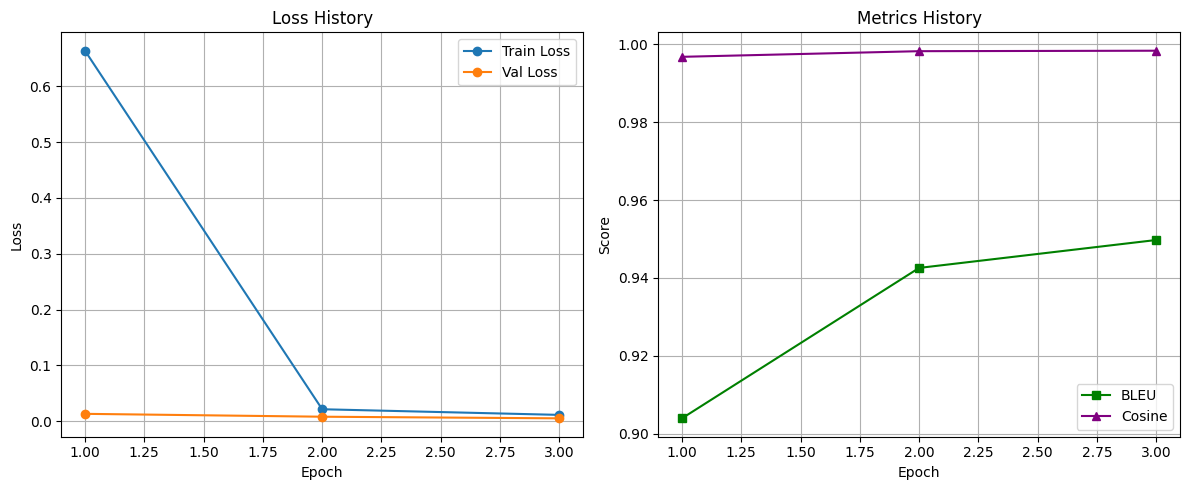


=== SAMPLE RECONSTRUCTIONS ===
Input:  feel man soul strong
Target: man feel strong soul
Pred:   man feel strong soul
------------------------------
Input:  emerges cobra ripple water
Target: cobra emerges water ripple
Pred:   cobra emerges water ripple
------------------------------
Input:  servant makes loaf bread
Target: servant makes loaf bread
Pred:   servant makes loaf bread
------------------------------
Input:  stone finds youth ring
Target: youth finds stone ring
Pred:   youth finds stone ring
------------------------------
Input:  guide father youth road
Target: father guide youth road
Pred:   father guide youth road
------------------------------
Input:  honor maat people feather
Target: people honor maat feather
Pred:   people honor maat feather
------------------------------
Input:  god throne people praise
Target: people praise god throne
Pred:   people praise god throne
------------------------------
Input:  servant basket lord bring
Target: servant bring basket lord
Pr

In [42]:
import torch
import random
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from transformers import BartTokenizer, BartForConditionalGeneration, get_linear_schedule_with_warmup
from nltk.translate.bleu_score import sentence_bleu
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================

# Clean the inputs: Convert multiline strings to space-separated strings
original_shuffled = [s.replace("\n", " ").strip() for s in shuffled_sentences_raw]

# ==========================================
# 2. DATA AUGMENTATION
# ==========================================

print("Generating augmented data...")

def augment_data(ground_truth_list, num_augmentations=10):
    """
    Creates multiple shuffled versions of each ground truth sentence.
    This helps the model learn to reorder words generally.
    """
    inputs = []
    targets = []
    
    for sentence in ground_truth_list:
        words = sentence.split()
        
        # Generate 'num_augmentations' different shuffles for each sentence
        for _ in range(num_augmentations):
            shuffled_words = words.copy()
            random.shuffle(shuffled_words)
            inputs.append(" ".join(shuffled_words))
            targets.append(sentence)
            
    return inputs, targets

# Perform heavy augmentation (600 sentences * 10 = 6000 examples)
aug_inputs, aug_targets = augment_data(merged_ground_truth_sentences, num_augmentations=10)

# Combine original specific challenges with augmented data
all_inputs = aug_inputs + original_shuffled
all_targets = aug_targets + merged_ground_truth_sentences

# Create a DataFrame
df = pd.DataFrame({'input_text': all_inputs, 'target_text': all_targets})
print(f"Total dataset size after augmentation: {len(df)}")

# ==========================================
# 3. DATASET & DATALOADER
# ==========================================

class SentenceReconstructionDataset(Dataset):
    def __init__(self, tokenizer, data, max_len=32):
        self.tokenizer = tokenizer
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        source = str(self.data.iloc[index]['input_text'])
        target = str(self.data.iloc[index]['target_text'])

        source_tok = self.tokenizer(
            source, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        target_tok = self.tokenizer(
            target, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        return {
            'input_ids': source_tok['input_ids'].flatten(),
            'attention_mask': source_tok['attention_mask'].flatten(),
            'labels': target_tok['input_ids'].flatten()
        }

# ==========================================
# 4. MODEL SETUP (BART)
# ==========================================

MODEL_NAME = "facebook/bart-base" 

print(f"Loading {MODEL_NAME} model...")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Split Data
train_size = int(0.8 * len(df))
val_size = len(df) - train_size
# random_split returns Subset objects
train_subset, val_subset = random_split(range(len(df)), [train_size, val_size])

# Create Subsets using .indices to get the actual integer list for pandas iloc
train_df = df.iloc[list(train_subset.indices)].reset_index(drop=True)
val_df = df.iloc[list(val_subset.indices)].reset_index(drop=True)

train_set = SentenceReconstructionDataset(tokenizer, train_df)
val_set = SentenceReconstructionDataset(tokenizer, val_df)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)

optimizer = AdamW(model.parameters(), lr=5e-5)
epochs = 3

# ==========================================
# 5. METRICS HELPER
# ==========================================

try:
    from sentence_transformers import SentenceTransformer
    sim_model = SentenceTransformer('all-MiniLM-L6-v2')
    calc_cosine = True
except ImportError:
    print("sentence-transformers not installed. Cosine similarity will be skipped.")
    calc_cosine = False

def calculate_metrics(predictions, references):
    # BLEU
    bleu_scores = [sentence_bleu([ref.split()], pred.split()) for pred, ref in zip(predictions, references)]
    avg_bleu = np.mean(bleu_scores)

    # Cosine Similarity
    avg_cosine = 0.0
    if calc_cosine:
        pred_embeddings = sim_model.encode(predictions)
        ref_embeddings = sim_model.encode(references)
        cos_sims = cosine_similarity(pred_embeddings, ref_embeddings).diagonal()
        avg_cosine = np.mean(cos_sims)
    
    return avg_bleu, avg_cosine

# ==========================================
# 6. TRAINING LOOP
# ==========================================

history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'bleu': [],
    'cosine': []
}

print("Starting training...")

for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        total_train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION ---
    model.eval()
    total_val_loss = 0
    predictions = []
    references = []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
            
            generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=32)
            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
            
            predictions.extend(decoded_preds)
            references.extend(decoded_labels)

    avg_val_loss = total_val_loss / len(val_loader)
    bleu, cosine = calculate_metrics(predictions, references)
    
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['bleu'].append(bleu)
    history['cosine'].append(cosine)
    
    print(f"Epoch {epoch+1} Results: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | BLEU: {bleu:.4f} | Cosine: {cosine:.4f}")

# ==========================================
# 7. RESULTS & VISUALIZATION
# ==========================================

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['epoch'], history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss History')
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.legend(), plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['bleu'], label='BLEU', marker='s', color='green')
if calc_cosine:
    plt.plot(history['epoch'], history['cosine'], label='Cosine', marker='^', color='purple')
plt.title('Metrics History')
plt.xlabel('Epoch'), plt.ylabel('Score'), plt.legend(), plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== SAMPLE RECONSTRUCTIONS ===")
sample_indices = random.sample(range(len(predictions)), min(10, len(predictions)))
for i in sample_indices:
    print(f"Input:  {val_df.iloc[i]['input_text']}")
    print(f"Target: {references[i]}")
    print(f"Pred:   {predictions[i]}")
    print("-" * 30)

# Save results
pd.DataFrame(history).to_csv('training_metrics.csv', index=False)
pd.DataFrame({'Input': val_df['input_text'], 'Target': references, 'Prediction': predictions}).to_csv('reconstruction_results.csv', index=False)
print("\nResults and metrics saved to local CSV files.")